<a href="https://colab.research.google.com/github/Hajim5/BeyondYOLO/blob/main/SmallCNN_2Output_Training_with_Mistakes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SmallCNN 2-Output Training

Dataset:
- `0` = EMPTY
- `1` = CUP
- `2` = UNDEFINED

Model outputs:
- Output 0 = CUP vs EMPTY
- Output 1 = UNDEFINED

Targets:
- EMPTY → `[0, 0]`
- CUP → `[1, 0]`
- UNDEFINED → `[0, 1]`

The CNN remains the same `16 → 32 → 64` SmallCNN with a `64 → 2` classifier.


In [43]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="aIuJiuSXzAmwEQFYVFMD")
project = rf.workspace("hazimsensoryai").project("generalstation")
version = project.version(19)
dataset = version.download("folder")


loading Roboflow workspace...
loading Roboflow project...


In [44]:
# ============================================================
# 1. IMPORTS / CONFIGURATION
# ============================================================

import os
import time
import copy
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

DATASET_ROOT = "/content/GeneralStation-19"

TRAIN_PATH = os.path.join(DATASET_ROOT, "train")
VALID_PATH = os.path.join(DATASET_ROOT, "valid")
TEST_PATH = os.path.join(DATASET_ROOT, "test")

IMAGE_SIZE = 64
BATCH_SIZE = 32
NUM_EPOCHS = 40
LEARNING_RATE = 0.001
THRESHOLD = 0.55

CLASS_NAMES = {
    0: "EMPTY",
    1: "CUP",
    2: "UNDEFINED"
}

print("=" * 70)
print("CONFIGURATION")
print("=" * 70)
print("Device:", device)
print("TRAIN:", TRAIN_PATH)
print("VALID:", VALID_PATH)
print("TEST :", TEST_PATH)
print("Image:", f"1 x {IMAGE_SIZE} x {IMAGE_SIZE}")
print("Batch size:", BATCH_SIZE)
print("Epochs:", NUM_EPOCHS)
print("Learning rate:", LEARNING_RATE)


CONFIGURATION
Device: cuda
TRAIN: /content/GeneralStation-18/train
VALID: /content/GeneralStation-18/valid
TEST : /content/GeneralStation-18/test
Image: 1 x 64 x 64
Batch size: 32
Epochs: 40
Learning rate: 0.001


In [45]:
# ============================================================
# 2. VERIFY DATASET STRUCTURE
# ============================================================

print("=" * 70)
print("DATASET STRUCTURE")
print("=" * 70)

for split_path in [TRAIN_PATH, VALID_PATH, TEST_PATH]:
    if not os.path.isdir(split_path):
        raise FileNotFoundError(split_path)

    for class_id in ["0", "1", "2"]:
        path = os.path.join(split_path, class_id)
        if not os.path.isdir(path):
            raise FileNotFoundError(path)

    print(split_path)
    for class_id in ["0", "1", "2"]:
        path = os.path.join(split_path, class_id)
        print(
            f"  {class_id} -> {CLASS_NAMES[int(class_id)]}: "
            f"{len(os.listdir(path))} files"
        )

print()
print("Dataset structure verified.")


DATASET STRUCTURE
/content/GeneralStation-18/train
  0 -> EMPTY: 3699 files
  1 -> CUP: 2682 files
  2 -> UNDEFINED: 1506 files
/content/GeneralStation-18/valid
  0 -> EMPTY: 347 files
  1 -> CUP: 262 files
  2 -> UNDEFINED: 142 files
/content/GeneralStation-18/test
  0 -> EMPTY: 159 files
  1 -> CUP: 140 files
  2 -> UNDEFINED: 76 files

Dataset structure verified.


In [46]:
# ============================================================
# 3. TRANSFORMS
# ============================================================

# Same preprocessing as the original SmallCNN:
# Grayscale -> 64x64 -> Tensor -> Normalize(0.5, 0.5)

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

print("=" * 70)
print("TRANSFORMS")
print("=" * 70)
print("Grayscale: 1 channel")
print("Resize: 64 x 64")
print("Normalize: mean=0.5, std=0.5")


TRANSFORMS
Grayscale: 1 channel
Resize: 64 x 64
Normalize: mean=0.5, std=0.5


In [47]:
# ============================================================
# 4. LOAD IMAGEFOLDER DATASETS
# ============================================================

base_train = datasets.ImageFolder(
    TRAIN_PATH,
    transform=transform
)

base_valid = datasets.ImageFolder(
    VALID_PATH,
    transform=transform
)

base_test = datasets.ImageFolder(
    TEST_PATH,
    transform=transform
)

expected = {"0": 0, "1": 1, "2": 2}

print("=" * 70)
print("CLASS MAPPING")
print("=" * 70)

print("Train:", base_train.class_to_idx)
print("Valid:", base_valid.class_to_idx)
print("Test :", base_test.class_to_idx)

for ds in [base_train, base_valid, base_test]:
    if ds.class_to_idx != expected:
        raise ValueError(
            f"Unexpected mapping: {ds.class_to_idx}"
        )

print()
print("0 = EMPTY")
print("1 = CUP")
print("2 = UNDEFINED")


CLASS MAPPING
Train: {'0': 0, '1': 1, '2': 2}
Valid: {'0': 0, '1': 1, '2': 2}
Test : {'0': 0, '1': 1, '2': 2}

0 = EMPTY
1 = CUP
2 = UNDEFINED


In [48]:
# ============================================================
# 5. TWO-OUTPUT DATASET
# ============================================================

class TwoOutputDataset(Dataset):

    def __init__(self, image_folder):
        self.dataset = image_folder

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):

        image, class_index = self.dataset[index]

        # Output 0 = CUP/EMPTY
        # Output 1 = UNDEFINED

        if class_index == 0:
            target = [0.0, 0.0]       # EMPTY

        elif class_index == 1:
            target = [1.0, 0.0]       # CUP

        elif class_index == 2:
            target = [0.0, 1.0]       # UNDEFINED

        else:
            raise ValueError(class_index)

        target = torch.tensor(
            target,
            dtype=torch.float32
        )

        return image, target, class_index


train_dataset = TwoOutputDataset(base_train)
valid_dataset = TwoOutputDataset(base_valid)
test_dataset = TwoOutputDataset(base_test)

print("=" * 70)
print("TARGET ENCODING")
print("=" * 70)
print("EMPTY     -> [0, 0]")
print("CUP       -> [1, 0]")
print("UNDEFINED -> [0, 1]")


TARGET ENCODING
EMPTY     -> [0, 0]
CUP       -> [1, 0]
UNDEFINED -> [0, 1]


In [49]:
# ============================================================
# 6. DATASET SIZES / LOADERS
# ============================================================

print("=" * 70)
print("DATASET SIZES")
print("=" * 70)

print("Training images:", len(train_dataset))
print("Validation images:", len(valid_dataset))
print("Test images:", len(test_dataset))

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print()
print("Train batches:", len(train_loader))
print("Valid batches:", len(valid_loader))
print("Test batches :", len(test_loader))


DATASET SIZES
Training images: 7887
Validation images: 751
Test images: 375

Train batches: 247
Valid batches: 24
Test batches : 12


In [50]:
# ============================================================
# 7. SMALLCNN
# ============================================================

class SmallCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                1, 16,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(
                16, 32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(
                32, 64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Output 0 = CUP/EMPTY
        # Output 1 = UNDEFINED
        self.classifier = nn.Linear(64, 2)

    def forward(self, x):

        x = self.features(x)
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)

        return x


model = SmallCNN().to(device)

total_parameters = sum(
    p.numel() for p in model.parameters()
)

print("=" * 70)
print("SMALL CNN ARCHITECTURE")
print("=" * 70)
print(model)
print()
print("Parameters:", f"{total_parameters:,}")


SMALL CNN ARCHITECTURE
SmallCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
  )
  (global_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Linear(in_features=64, out_features=2, bias=True)
)

Parameters: 23,650


In [51]:
# ============================================================
# 8. LOSS / OPTIMIZER
# ============================================================

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("=" * 70)
print("TRAINING CONFIGURATION")
print("=" * 70)
print("Loss:", "BCEWithLogitsLoss")
print("Optimizer:", "Adam")
print("Learning rate:", LEARNING_RATE)


TRAINING CONFIGURATION
Loss: BCEWithLogitsLoss
Optimizer: Adam
Learning rate: 0.001


In [52]:
# ============================================================
# 9. CONVERT MODEL OUTPUTS TO 3 CLASSES
# ============================================================

def outputs_to_classes(logits, threshold=0.5):

    probabilities = torch.sigmoid(logits)

    cup_probability = probabilities[:, 0]
    undefined_probability = probabilities[:, 1]

    predictions = torch.zeros(
        logits.size(0),
        dtype=torch.long,
        device=logits.device
    )

    # Undefined has priority.
    undefined_mask = (
        undefined_probability >= threshold
    )

    predictions[undefined_mask] = 2

    # Otherwise classify CUP vs EMPTY.
    cup_mask = (
        (cup_probability >= threshold)
        &
        (~undefined_mask)
    )

    predictions[cup_mask] = 1

    return predictions, probabilities


In [53]:
# ============================================================
# 10. TRAIN / EVALUATE FUNCTIONS
# ============================================================

def train_one_epoch():

    model.train()

    total_loss = 0.0
    total_samples = 0

    for images, targets, _ in train_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        targets = targets.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        logits = model(images)

        loss = criterion(
            logits,
            targets
        )

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)

        total_loss += (
            loss.item() * batch_size
        )

        total_samples += batch_size

    return total_loss / total_samples


def evaluate(loader):

    model.eval()

    total_loss = 0.0
    total_samples = 0

    targets_all = []
    predictions_all = []

    with torch.no_grad():

        for images, targets, class_indices in loader:

            images = images.to(device)
            targets = targets.to(device)

            logits = model(images)

            loss = criterion(
                logits,
                targets
            )

            predictions, _ = outputs_to_classes(
                logits,
                THRESHOLD
            )

            batch_size = images.size(0)

            total_loss += (
                loss.item() * batch_size
            )

            total_samples += batch_size

            targets_all.extend(
                class_indices.numpy().tolist()
            )

            predictions_all.extend(
                predictions.cpu().numpy().tolist()
            )

    targets_all = np.array(targets_all)
    predictions_all = np.array(predictions_all)

    return {
        "loss": total_loss / total_samples,
        "accuracy": accuracy_score(
            targets_all,
            predictions_all
        ),
        "balanced_accuracy": balanced_accuracy_score(
            targets_all,
            predictions_all
        ),
        "targets": targets_all,
        "predictions": predictions_all
    }


In [54]:
# ============================================================
# 11. TRAINING
# ============================================================

history = {
    "train_loss": [],
    "valid_loss": [],
    "valid_accuracy": [],
    "valid_balanced_accuracy": []
}

best_state = None
best_balanced_accuracy = -1.0

print("=" * 70)
print("TRAINING SMALLCNN")
print("=" * 70)

training_start = time.perf_counter()

for epoch in range(1, NUM_EPOCHS + 1):

    start = time.perf_counter()

    train_loss = train_one_epoch()

    valid = evaluate(valid_loader)

    history["train_loss"].append(train_loss)
    history["valid_loss"].append(valid["loss"])
    history["valid_accuracy"].append(valid["accuracy"])
    history["valid_balanced_accuracy"].append(
        valid["balanced_accuracy"]
    )

    if (
        valid["balanced_accuracy"]
        > best_balanced_accuracy
    ):

        best_balanced_accuracy = (
            valid["balanced_accuracy"]
        )

        best_state = copy.deepcopy(
            model.state_dict()
        )

    elapsed = time.perf_counter() - start

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Valid Loss: {valid['loss']:.4f} | "
        f"Valid Acc: {valid['accuracy'] * 100:.2f}% | "
        f"Valid Bal Acc: {valid['balanced_accuracy'] * 100:.2f}% | "
        f"Time: {elapsed:.2f}s"
    )

if best_state is not None:
    model.load_state_dict(best_state)

training_time = time.perf_counter() - training_start

print()
print("Training complete.")
print(
    "Total training time:",
    f"{training_time:.2f} seconds"
)
print(
    "Best validation balanced accuracy:",
    f"{best_balanced_accuracy * 100:.2f}%"
)


TRAINING SMALLCNN
Epoch 01/40 | Train Loss: 0.3843 | Valid Loss: 0.2876 | Valid Acc: 80.03% | Valid Bal Acc: 78.92% | Time: 15.95s
Epoch 02/40 | Train Loss: 0.2543 | Valid Loss: 0.2046 | Valid Acc: 82.02% | Valid Bal Acc: 81.48% | Time: 13.21s
Epoch 03/40 | Train Loss: 0.2088 | Valid Loss: 0.1675 | Valid Acc: 89.88% | Valid Bal Acc: 91.57% | Time: 8.31s
Epoch 04/40 | Train Loss: 0.1850 | Valid Loss: 0.1331 | Valid Acc: 92.81% | Valid Bal Acc: 93.14% | Time: 8.77s
Epoch 05/40 | Train Loss: 0.1659 | Valid Loss: 0.1238 | Valid Acc: 91.61% | Valid Bal Acc: 90.56% | Time: 7.19s
Epoch 06/40 | Train Loss: 0.1507 | Valid Loss: 0.7737 | Valid Acc: 53.66% | Valid Bal Acc: 63.43% | Time: 8.44s
Epoch 07/40 | Train Loss: 0.1443 | Valid Loss: 0.2933 | Valid Acc: 73.77% | Valid Bal Acc: 74.50% | Time: 7.37s
Epoch 08/40 | Train Loss: 0.1403 | Valid Loss: 0.0971 | Valid Acc: 94.81% | Valid Bal Acc: 94.26% | Time: 8.14s
Epoch 09/40 | Train Loss: 0.1268 | Valid Loss: 0.3581 | Valid Acc: 72.70% | Valid Ba

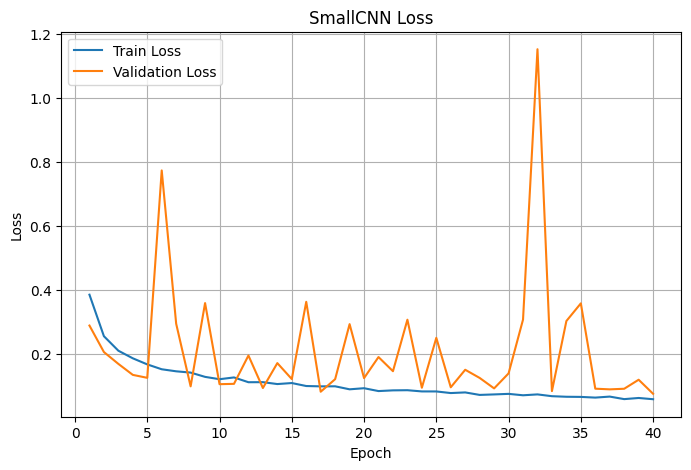

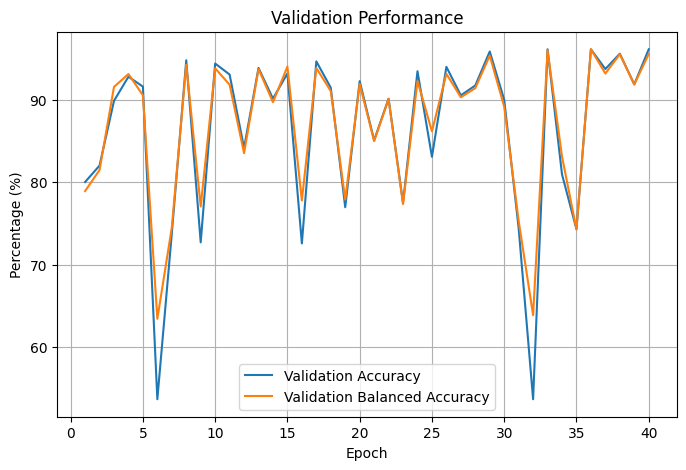

In [55]:
# ============================================================
# 12. TRAINING CURVES
# ============================================================

epochs = range(
    1,
    len(history["train_loss"]) + 1
)

plt.figure(figsize=(8, 5))
plt.plot(
    epochs,
    history["train_loss"],
    label="Train Loss"
)
plt.plot(
    epochs,
    history["valid_loss"],
    label="Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SmallCNN Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    epochs,
    np.array(history["valid_accuracy"]) * 100,
    label="Validation Accuracy"
)
plt.plot(
    epochs,
    np.array(history["valid_balanced_accuracy"]) * 100,
    label="Validation Balanced Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Percentage (%)")
plt.title("Validation Performance")
plt.legend()
plt.grid(True)
plt.show()


In [56]:
# ============================================================
# 13. TEST EVALUATION
# ============================================================

test = evaluate(test_loader)

test_targets = test["targets"]
test_predictions = test["predictions"]

test_accuracy = test["accuracy"]
test_balanced_accuracy = test["balanced_accuracy"]

print("=" * 70)
print("TEST RESULTS")
print("=" * 70)

print()
print(
    "Test accuracy:",
    f"{test_accuracy * 100:.2f}%"
)

print(
    "Balanced accuracy:",
    f"{test_balanced_accuracy * 100:.2f}%"
)


TEST RESULTS

Test accuracy: 98.40%
Balanced accuracy: 98.23%


CONFUSION MATRIX

[[157   0   2]
 [  1 138   1]
 [  2   0  74]]

Rows = Actual
Columns = Predicted
Order = EMPTY, CUP, UNDEFINED


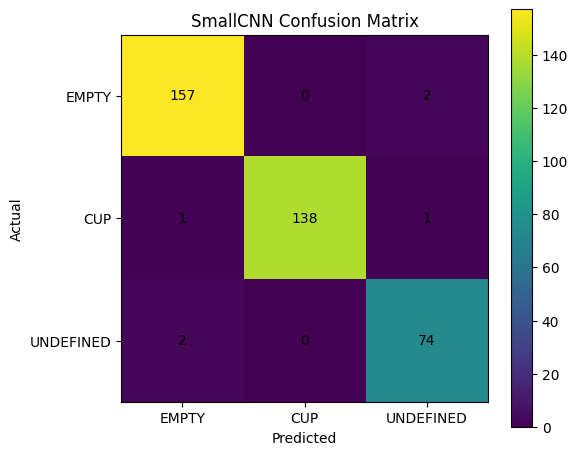

In [57]:
# ============================================================
# 14. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    test_targets,
    test_predictions,
    labels=[0, 1, 2]
)

print("=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)
print()
print(cm)
print()
print("Rows = Actual")
print("Columns = Predicted")
print("Order = EMPTY, CUP, UNDEFINED")

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("SmallCNN Confusion Matrix")
plt.colorbar()

plt.xticks(
    [0, 1, 2],
    ["EMPTY", "CUP", "UNDEFINED"]
)

plt.yticks(
    [0, 1, 2],
    ["EMPTY", "CUP", "UNDEFINED"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(3):
    for j in range(3):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()


MISCLASSIFIED TEST IMAGES

Total test images: 375
Misclassified: 6
Test errors: 1.60%

Mistake summary:

Actual: EMPTY
Predicted: UNDEFINED
CUP probability: 0.23%
UNDEFINED probability: 80.75%
File: /content/GeneralStation-18/test/0/Philipenes4_S5_BASELINE_HIGH_0006_jpg.rf.94178a95895a6b89bee99ace2e7536d3.jpg

Actual: EMPTY
Predicted: UNDEFINED
CUP probability: 1.43%
UNDEFINED probability: 82.04%
File: /content/GeneralStation-18/test/0/S5_UNDEFINED_000024_jpg.rf.5147f672182fada78228ec34b4453d21.jpg

Actual: CUP
Predicted: EMPTY
CUP probability: 45.43%
UNDEFINED probability: 15.30%
File: /content/GeneralStation-18/test/1/Philipenes4_E2_BASELINE_CENTER_0005_jpg.rf.02c327d7d5340f5148dabb1899cfdea9.jpg

Actual: CUP
Predicted: UNDEFINED
CUP probability: 21.78%
UNDEFINED probability: 88.12%
File: /content/GeneralStation-18/test/1/Philipenes4_S2_LOW_0002_jpg.rf.79ca754c0413924376abd7a531c4663d.jpg

Actual: UNDEFINED
Predicted: EMPTY
CUP probability: 41.51%
UNDEFINED probability: 12.94%
File: 

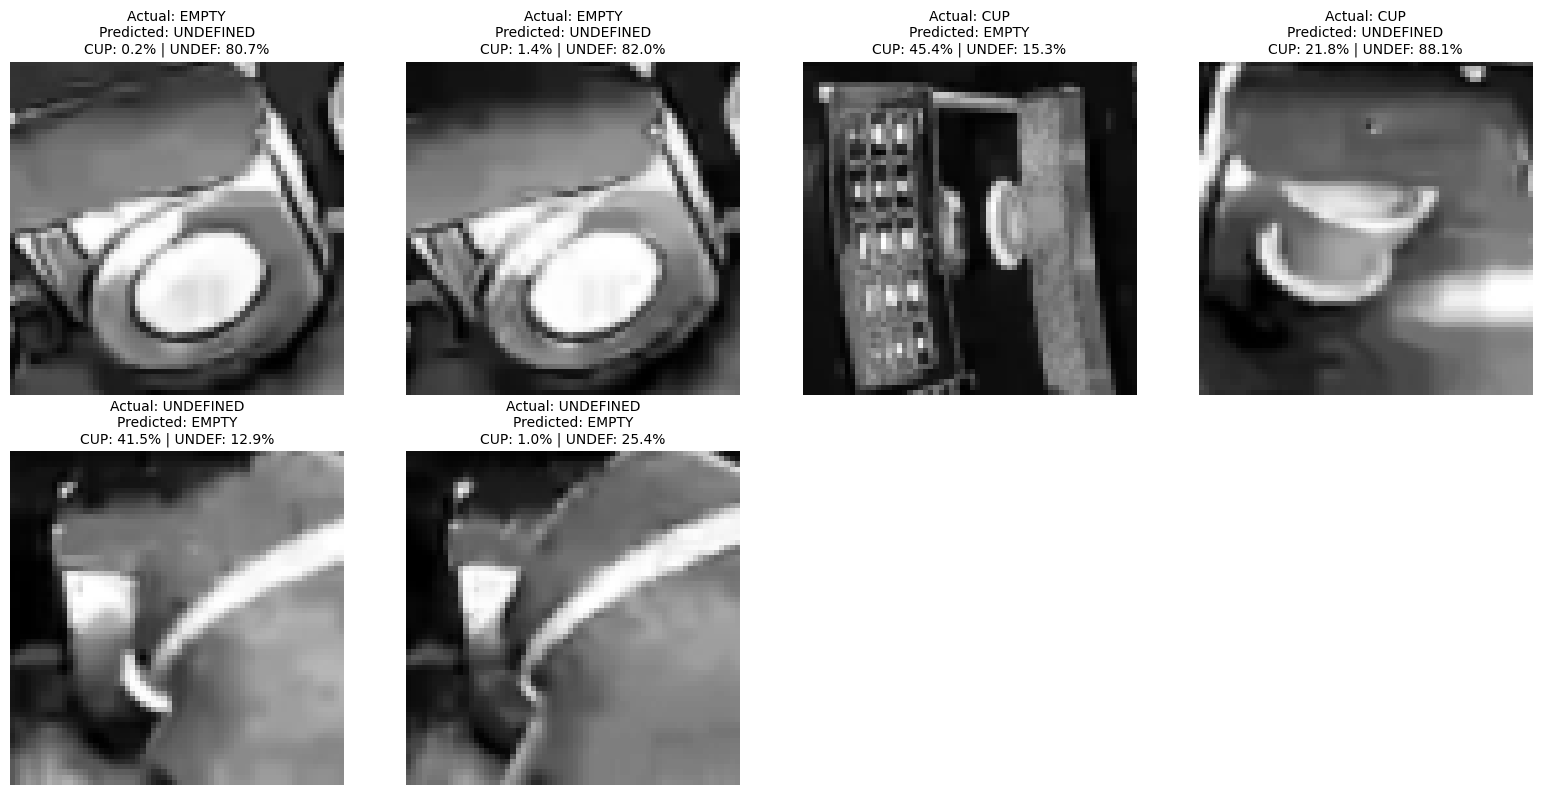


Misclassified images saved to:
/content/misclassified_test_images

You can inspect each mistake type in separate folders.


In [58]:
# ============================================================
# 15B. SHOW MISCLASSIFIED TEST IMAGES
# ============================================================
#
# This shows the actual test images that the model predicted
# incorrectly.
#
# Each image shows:
#   Actual
#   Predicted
#   CUP probability
#   UNDEFINED probability
#
# This is useful for finding out WHY the model is making
# mistakes, e.g.:
#
#   CUP -> EMPTY
#   EMPTY -> CUP
#   CUP -> UNDEFINED
#   EMPTY -> UNDEFINED
#   UNDEFINED -> CUP
#   UNDEFINED -> EMPTY
#
# ============================================================

model.eval()

misclassified = []

with torch.no_grad():

    for index in range(len(test_dataset)):

        image, _, actual_class = test_dataset[index]

        input_tensor = image.unsqueeze(0).to(device)

        logits = model(input_tensor)

        prediction_tensor, probabilities = outputs_to_classes(
            logits,
            THRESHOLD
        )

        predicted_class = int(
            prediction_tensor.item()
        )

        cup_probability = float(
            probabilities[0, 0].item()
        )

        undefined_probability = float(
            probabilities[0, 1].item()
        )

        actual_class = int(actual_class)

        if predicted_class != actual_class:

            # ImageFolder stores the original file path here.
            image_path = base_test.samples[index][0]

            misclassified.append({
                "index": index,
                "image": image.cpu(),
                "actual": actual_class,
                "predicted": predicted_class,
                "cup_probability": cup_probability,
                "undefined_probability": undefined_probability,
                "path": image_path
            })


print("=" * 70)
print("MISCLASSIFIED TEST IMAGES")
print("=" * 70)

print()
print(
    f"Total test images: {len(test_dataset)}"
)

print(
    f"Misclassified: {len(misclassified)}"
)

print(
    f"Test errors: "
    f"{len(misclassified) / len(test_dataset) * 100:.2f}%"
)

if len(misclassified) == 0:

    print()
    print("No misclassified test images.")

else:

    print()
    print("Mistake summary:")

    for item in misclassified:

        actual_name = CLASS_NAMES[
            item["actual"]
        ]

        predicted_name = CLASS_NAMES[
            item["predicted"]
        ]

        print()
        print(
            f"Actual: {actual_name}"
        )

        print(
            f"Predicted: {predicted_name}"
        )

        print(
            f"CUP probability: "
            f"{item['cup_probability'] * 100:.2f}%"
        )

        print(
            f"UNDEFINED probability: "
            f"{item['undefined_probability'] * 100:.2f}%"
        )

        print(
            f"File: {item['path']}"
        )


# ============================================================
# DISPLAY MISCLASSIFIED IMAGES
# ============================================================

if len(misclassified) > 0:

    MAX_IMAGES_TO_SHOW = 30

    images_to_show = misclassified[
        :MAX_IMAGES_TO_SHOW
    ]

    columns = 4

    rows = int(
        np.ceil(
            len(images_to_show) / columns
        )
    )

    plt.figure(
        figsize=(
            16,
            rows * 4
        )
    )

    for plot_index, item in enumerate(
        images_to_show
    ):

        image = item["image"]

        # Undo Normalize([0.5], [0.5])
        # normalized = (pixel - 0.5) / 0.5
        # pixel = normalized * 0.5 + 0.5

        image = (
            image[0].numpy() * 0.5
            + 0.5
        )

        image = np.clip(
            image,
            0,
            1
        )

        actual_name = CLASS_NAMES[
            item["actual"]
        ]

        predicted_name = CLASS_NAMES[
            item["predicted"]
        ]

        plt.subplot(
            rows,
            columns,
            plot_index + 1
        )

        plt.imshow(
            image,
            cmap="gray"
        )

        plt.title(
            f"Actual: {actual_name}\n"
            f"Predicted: {predicted_name}\n"
            f"CUP: {item['cup_probability'] * 100:.1f}% | "
            f"UNDEF: {item['undefined_probability'] * 100:.1f}%",
            fontsize=10
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()


# ============================================================
# SAVE MISCLASSIFIED IMAGES
# ============================================================
#
# This creates:
#
# /content/misclassified_test_images/
#
# with the original test images copied into folders based on
# the type of mistake.
#
# Example:
#
# CUP_to_EMPTY/
# EMPTY_to_CUP/
# CUP_to_UNDEFINED/
#
# ============================================================

import shutil

MISCLASSIFIED_DIR = (
    "/content/misclassified_test_images"
)

os.makedirs(
    MISCLASSIFIED_DIR,
    exist_ok=True
)


for item in misclassified:

    actual_name = CLASS_NAMES[
        item["actual"]
    ]

    predicted_name = CLASS_NAMES[
        item["predicted"]
    ]

    mistake_folder = (
        f"{actual_name}_to_{predicted_name}"
    )

    output_folder = os.path.join(
        MISCLASSIFIED_DIR,
        mistake_folder
    )

    os.makedirs(
        output_folder,
        exist_ok=True
    )

    original_path = item["path"]

    original_name = os.path.basename(
        original_path
    )

    output_path = os.path.join(
        output_folder,
        original_name
    )

    shutil.copy2(
        original_path,
        output_path
    )


print()
print(
    "Misclassified images saved to:"
)

print(
    MISCLASSIFIED_DIR
)

print()
print(
    "You can inspect each mistake type in separate folders."
)


In [59]:
# ============================================================
# 15. METRICS
# ============================================================

print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        test_targets,
        test_predictions,
        labels=[0, 1, 2],
        target_names=[
            "EMPTY",
            "CUP",
            "UNDEFINED"
        ],
        digits=4,
        zero_division=0
    )
)


cup_precision = precision_score(
    test_targets,
    test_predictions,
    labels=[1],
    average="macro",
    zero_division=0
)

cup_recall = recall_score(
    test_targets,
    test_predictions,
    labels=[1],
    average="macro",
    zero_division=0
)

cup_f1 = f1_score(
    test_targets,
    test_predictions,
    labels=[1],
    average="macro",
    zero_division=0
)


# EMPTY specificity:
# EMPTY is the negative class;
# CUP and UNDEFINED are treated as non-EMPTY.

empty_actual = test_targets == 0
empty_predicted = test_predictions == 0

tn = np.sum(
    (~empty_actual) &
    (~empty_predicted)
)

fp = np.sum(
    (~empty_actual) &
    empty_predicted
)

empty_specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0.0
)


print("=" * 70)
print("SELECTED METRICS")
print("=" * 70)

print()
print(
    "Test accuracy          :",
    f"{test_accuracy * 100:.2f}%"
)

print(
    "Balanced accuracy      :",
    f"{test_balanced_accuracy * 100:.2f}%"
)

print(
    "CUP precision          :",
    f"{cup_precision * 100:.2f}%"
)

print(
    "CUP recall             :",
    f"{cup_recall * 100:.2f}%"
)

print(
    "EMPTY specificity      :",
    f"{empty_specificity * 100:.2f}%"
)

print(
    "CUP F1                 :",
    f"{cup_f1 * 100:.2f}%"
)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

       EMPTY     0.9812    0.9874    0.9843       159
         CUP     1.0000    0.9857    0.9928       140
   UNDEFINED     0.9610    0.9737    0.9673        76

    accuracy                         0.9840       375
   macro avg     0.9808    0.9823    0.9815       375
weighted avg     0.9842    0.9840    0.9840       375

SELECTED METRICS

Test accuracy          : 98.40%
Balanced accuracy      : 98.23%
CUP precision          : 100.00%
CUP recall             : 98.57%
EMPTY specificity      : 98.61%
CUP F1                 : 99.28%


In [60]:
# ============================================================
# 16. INFERENCE TIME
# ============================================================

model.eval()

sample_image, _, _ = test_dataset[0]

sample_input = sample_image.unsqueeze(
    0
).to(device)

with torch.no_grad():
    for _ in range(20):
        model(sample_input)

if device.type == "cuda":
    torch.cuda.synchronize()

runs = 1000

start = time.perf_counter()

with torch.no_grad():
    for _ in range(runs):
        model(sample_input)

if device.type == "cuda":
    torch.cuda.synchronize()

elapsed = time.perf_counter() - start

inference_ms_per_image = (
    elapsed / runs * 1000
)

fps = 1000 / inference_ms_per_image

print("=" * 70)
print("INFERENCE PERFORMANCE")
print("=" * 70)

print()
print(
    "Inference:",
    f"{inference_ms_per_image:.4f} ms/image"
)

print(
    "Approx FPS:",
    f"{fps:.2f}"
)


INFERENCE PERFORMANCE

Inference: 0.5618 ms/image
Approx FPS: 1780.00


In [61]:
# ============================================================
# 17. SAVE MODEL
# ============================================================

MODEL_SAVE_PATH = (
    "/content/SmallCNN_2Output.pth"
)

checkpoint = {
    "model_state_dict": model.state_dict(),
    "model_name": "SmallCNN_2Output",
    "input_channels": 1,
    "input_size": IMAGE_SIZE,
    "architecture": "16 -> 32 -> 64",
    "output_size": 2,

    "output_definition": {
        "output_0": "CUP vs EMPTY",
        "output_1": "UNDEFINED"
    },

    "class_mapping": {
        "0": "EMPTY",
        "1": "CUP",
        "2": "UNDEFINED"
    },

    "target_mapping": {
        "EMPTY": [0.0, 0.0],
        "CUP": [1.0, 0.0],
        "UNDEFINED": [0.0, 1.0]
    },

    "threshold": THRESHOLD,
    "total_parameters": total_parameters,

    "test_accuracy": test_accuracy,
    "test_balanced_accuracy": test_balanced_accuracy,
    "cup_precision": cup_precision,
    "cup_recall": cup_recall,
    "empty_specificity": empty_specificity,
    "cup_f1": cup_f1
}

torch.save(
    checkpoint,
    MODEL_SAVE_PATH
)

print("=" * 70)
print("MODEL SAVED")
print("=" * 70)
print("Path:", MODEL_SAVE_PATH)


MODEL SAVED
Path: /content/SmallCNN_2Output.pth


In [62]:
# ============================================================
# 18. VERIFY SAVED MODEL
# ============================================================

loaded_checkpoint = torch.load(
    MODEL_SAVE_PATH,
    map_location=device,
    weights_only=False
)

loaded_model = SmallCNN().to(device)

loaded_model.load_state_dict(
    loaded_checkpoint["model_state_dict"]
)

loaded_model.eval()

print("=" * 70)
print("MODEL LOAD TEST")
print("=" * 70)

print(
    "Model:",
    loaded_checkpoint["model_name"]
)

print(
    "Parameters:",
    f"{loaded_checkpoint['total_parameters']:,}"
)

print(
    "Class mapping:",
    loaded_checkpoint["class_mapping"]
)

print(
    "Output definition:",
    loaded_checkpoint["output_definition"]
)

print(
    "Target mapping:",
    loaded_checkpoint["target_mapping"]
)

print(
    "Model loaded successfully."
)


MODEL LOAD TEST
Model: SmallCNN_2Output
Parameters: 23,650
Class mapping: {'0': 'EMPTY', '1': 'CUP', '2': 'UNDEFINED'}
Output definition: {'output_0': 'CUP vs EMPTY', 'output_1': 'UNDEFINED'}
Target mapping: {'EMPTY': [0.0, 0.0], 'CUP': [1.0, 0.0], 'UNDEFINED': [0.0, 1.0]}
Model loaded successfully.


In [63]:
# ============================================================
# 19. FINAL SUMMARY
# ============================================================

print("=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

print(
    "Model                 :",
    "SmallCNN"
)

print(
    "Input                 :",
    "1 x 64 x 64"
)

print(
    "Architecture           :",
    "16 -> 32 -> 64 CNN"
)

print(
    "Output                :",
    "2"
)

print(
    "Output 0              :",
    "CUP / EMPTY"
)

print(
    "Output 1              :",
    "UNDEFINED"
)

print(
    "Loss                  :",
    "BCEWithLogitsLoss"
)

print(
    "Total parameters      :",
    f"{total_parameters:,}"
)

print(
    "Test accuracy         :",
    f"{test_accuracy * 100:.2f}%"
)

print(
    "Balanced accuracy     :",
    f"{test_balanced_accuracy * 100:.2f}%"
)

print(
    "CUP precision         :",
    f"{cup_precision * 100:.2f}%"
)

print(
    "CUP recall            :",
    f"{cup_recall * 100:.2f}%"
)

print(
    "EMPTY specificity     :",
    f"{empty_specificity * 100:.2f}%"
)

print(
    "CUP F1                :",
    f"{cup_f1 * 100:.2f}%"
)

print(
    "Inference             :",
    f"{inference_ms_per_image:.4f} ms/image"
)

print(
    "Approx FPS            :",
    f"{fps:.2f}"
)


FINAL SUMMARY
Model                 : SmallCNN
Input                 : 1 x 64 x 64
Architecture           : 16 -> 32 -> 64 CNN
Output                : 2
Output 0              : CUP / EMPTY
Output 1              : UNDEFINED
Loss                  : BCEWithLogitsLoss
Total parameters      : 23,650
Test accuracy         : 98.40%
Balanced accuracy     : 98.23%
CUP precision         : 100.00%
CUP recall            : 98.57%
EMPTY specificity     : 98.61%
CUP F1                : 99.28%
Inference             : 0.5618 ms/image
Approx FPS            : 1780.00
